# Cross-Method Consensus

**Final notebook of the spatiotemporal air quality anomaly detection pipeline**

---

Nine independent methods have each reached their own verdict about which stations show
anomalous reporting behaviour — spatial, temporal, multivariate, digit-pattern, and
density-based, none reading another's output. This notebook combines them into a single
ranked assessment: not by counting how many methods flag a station, but by asking what
*share* of the methods that could actually assess a station did flag it — a distinction that
matters materially once nine methods can assess very different subsets of the network.

| | |
|---|---|
| **Input** | Nine `station_suspicion_*.csv` files (Notebooks 03–11) |
| **Output** | `consensus_station_ranking.csv`, `consensus_summary_by_country.csv` |
| **Downstream** | `gfed5_crossref.ipynb` — fire cross-reference for the highest-ranked stations |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Input Loading
2. **Schema Verification**
   - 2.1 Schema Verification Across Methods
   - 2.2 Canonical Long-Format Table
3. **Coverage Structure**
   - 3.1 Methods Assessing Each Station
   - 3.2 Stations Assessed by Each Method
4. **Inter-Method Correlation Diagnostic**
   - 4.1 Pairwise Score Correlation
   - 4.2 Pairwise Flag Agreement
   - 4.3 Discriminative Power per Method
   - 4.4 Redundancy Assessment
5. **Consensus Score**
   - 5.1 Proportion, Not Raw Count
   - 5.2 Minimum Methods Assessed
6. **Direction Consensus**
7. **Caveat Propagation**
8. **Ranking and Flagging**
   - 8.1 Consensus Rate Sensitivity
   - 8.2 Flagging and Rank
9. **Results and Handoff**
   - 9.1 Top-Ranked Stations
   - 9.2 Consensus-Ready Output
   - 9.3 Output Validation
10. **Findings and Limitations**

---

Terminology

- A station is **assessed** by a method if that method could compute a suspicion score for
  it at all; a station a method cannot assess contributes neither a flag nor a clear vote to
  that method's share.
- The **consensus rate** is the share of the methods that assessed a station which also
  flagged it — `flagged_count / assessed_count` — not the raw count of methods that flagged
  it.
- **Method independence** means no detection notebook reads another's suspicion score or
  flag; this notebook is the first point at which the nine verdicts are combined.
- Two methods are **redundant** to the extent that they flag the same stations for the same
  underlying reason — agreement between redundant methods is weaker evidence than agreement
  between methods reasoning from genuinely different signals.
- A **caveat** is a documented reason to weight one method's contribution to a station's
  consensus more cautiously, without removing that contribution outright.


## 0. Method Context

### 0.1 Objective

Every method in this pipeline was built to stand alone: Notebook 03 never reads Notebook 04's
flags, Notebook 09 never reads Notebook 11's scores. That independence is a deliberate design
choice — nine methods reasoning from nine different statistical foundations, agreeing by
coincidence rather than by construction, is stronger evidence than any single method's
verdict. This notebook is the first point in the pipeline where that independence is
deliberately set aside: the nine verdicts are combined into one ranked list, because a CREA
report ultimately needs a prioritised set of stations to investigate, not nine separate
tables.

The combination is not a simple vote count. A station's geographic isolation, its
observation history, or its country's own data characteristics can leave it assessable by
six of the nine methods rather than all nine — through no fault of the station's own
behaviour. Investigated earlier in this pipeline's development: 449 stations are entirely
unassessable by the three spatial methods (Notebook 03, 06, 09) because they lack enough
geographic neighbours, yet every one of them is fully assessed by the six non-spatial
methods. A station like that must not be scored as "flagged by 3 of 9 methods" when its
honest denominator is 6, not 9 — that would make geographic isolation look like innocence.

Two objectives follow:

1. **Rank stations by the share of applicable methods that flagged them, not the raw
   count.** <br>A station flagged by 5 of 6 methods that could assess it is a stronger
   candidate than one flagged by 5 of 9, even though the raw count is identical — the first
   station triggered nearly every test that could be run on it.</br>

2. **Carry forward, rather than discard, the caveats already established for individual
   methods.** <br>The United States low-value asymmetry, Benford's country-level
   non-conformity, China's single-year observation window — none of these should be forgotten
   at the moment scores are combined; they inform how a specific station's consensus result
   should be read.</br>


### 0.2 Approach and Principles

Four decisions govern the implementation.

1. **Proportion, not count.** <br>The central quantity this notebook computes for every
   station is `flagged_count / assessed_count` — the share of applicable methods that
   flagged it — rather than a raw tally. This is the direct answer to the geographic-isolation
   problem identified during this pipeline's development.</br>

2. **Schema verification before combination.** <br>The nine source files were built across
   many sessions, and their column conventions are verified rather than assumed to match.
   Section 2 checks each file against the registry explicitly, as a visible step, so a future
   method arriving with a different convention fails loudly at that check rather than silently
   contributing a misread column.</br>

3. **A minimum number of assessing methods, derived rather than assumed.** <br>A station
   assessed by only one or two methods produces an unstable proportion — a single flag makes
   for a suspicion rate of 100%. Section 4.2 sets a floor below which a station's consensus
   rate is not reported as a ranking figure.</br>

4. **Caveats travel with the station, not just the method.** <br>Where an individual method
   has flagged a country-level caveat — Benford's `country_conforms`, for instance — that
   caveat is surfaced directly on any station in that network's consensus row, so a reviewer
   reading the final ranking sees it without needing to cross-reference nine source files.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `station_suspicion_zscore.csv` | Notebook 03 — spatial baseline |
| **In** | `station_suspicion_iforest.csv` | Notebook 04 — Isolation Forest |
| **In** | `station_suspicion_benford.csv` | Notebook 05 — Benford's Law |
| **In** | `station_suspicion_tsad.csv` | Notebook 06 — time-sliced spatial |
| **In** | `station_suspicion_lof.csv` | Notebook 07 — Local Outlier Factor |
| **In** | `station_suspicion_frozen.csv` | Notebook 08 — frozen values |
| **In** | `station_suspicion_slsh.csv` | Notebook 09 — SL/SH classification |
| **In** | `station_suspicion_dbscan.csv` | Notebook 10 — DBSCAN |
| **In** | `station_suspicion_autoencoder.csv` | Notebook 11 — autoencoder |
| **Out** | `consensus_station_ranking.csv` | Per-station consensus rate, rank, flag, direction, caveats |
| **Out** | `consensus_summary_by_country.csv` | Country-level rollup |

Notebook 12 (meteorology-aware detection) is not yet included: it has not been re-run since
its residual-scoring fix, and this notebook is written to make adding a tenth method a matter
of appending one entry to a list, not restructuring the notebook — the loop in Section 1.2
reads from a method registry, not nine hardcoded blocks.


## 1. Environment and Data

### 1.1 Configuration

The method registry below is the single place a tenth method would be added — a filename, a
short label, and which column in that file carries the assessed-indicator and the direction,
if any. Everything downstream reads this registry rather than naming methods individually.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

CONFIG_PATH = Path("../config/params.yml")
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

# Method registry: adding a tenth method (e.g. Notebook 12) means adding one entry here.
# "assessed_col" names the column in that source file marking a station as assessed.
# All nine now use the same name; the field is retained so a tenth method arriving with
# a different convention can be registered without editing anything downstream.
METHOD_REGISTRY = [
    {"file": "station_suspicion_zscore.csv",      "method": "zscore",      "assessed_col": "assessed"   ,  "has_direction": True},
    {"file": "station_suspicion_iforest.csv",      "method": "iforest",     "assessed_col": "assessed",    "has_direction": False},
    {"file": "station_suspicion_benford.csv",      "method": "benford",     "assessed_col": "assessed"  ,  "has_direction": False},
    {"file": "station_suspicion_tsad.csv",         "method": "tsad",        "assessed_col": "assessed"  ,  "has_direction": True},
    {"file": "station_suspicion_lof.csv",          "method": "lof",         "assessed_col": "assessed",    "has_direction": False},
    {"file": "station_suspicion_frozen.csv",       "method": "frozen",      "assessed_col": "assessed"  ,  "has_direction": False},
    {"file": "station_suspicion_slsh.csv",         "method": "slsh",        "assessed_col": "assessed"  ,  "has_direction": True},
    {"file": "station_suspicion_dbscan.csv",       "method": "dbscan",      "assessed_col": "assessed",    "has_direction": False},
    {"file": "station_suspicion_autoencoder.csv",  "method": "autoencoder", "assessed_col": "assessed",    "has_direction": False},
    # Notebook 12 uses "rankable" for its assessed indicator: a station is rankable when it
    # accumulated enough assessed hours for its anomaly rate to be stable. That is the same
    # concept the other files call "assessed", at station level.
    {"file": "station_suspicion_met_spatiotemporal.csv", "method": "met_spatiotemporal", "assessed_col": "rankable", "has_direction": True},
]
N_METHODS = len(METHOD_REGISTRY)

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

display(table_style(pd.DataFrame(METHOD_REGISTRY).set_index("method")))


,method,file,assessed_col,has_direction
0,zscore,station_suspicion_zscore.csv,assessed,True
1,iforest,station_suspicion_iforest.csv,assessed,False
2,benford,station_suspicion_benford.csv,assessed,False
3,tsad,station_suspicion_tsad.csv,assessed,True
4,lof,station_suspicion_lof.csv,assessed,False
5,frozen,station_suspicion_frozen.csv,assessed,False
6,slsh,station_suspicion_slsh.csv,assessed,True
7,dbscan,station_suspicion_dbscan.csv,assessed,False
8,autoencoder,station_suspicion_autoencoder.csv,assessed,False
9,met_spatiotemporal,station_suspicion_met_spatiotemporal.csv,rankable,True


<u>Interpretation</u>

Nine methods are registered, each pointing to its own source file and its own name for the
assessed-indicator column. The registry is the only place method-specific knowledge lives;
every section after this one operates generically over whatever is registered.


### 1.2 Input Loading

Each file is loaded and tagged with its method name before combination, so the origin of
every row survives the reshaping in Section 3.


In [2]:
raw_frames = {}
missing_files = []

for entry in METHOD_REGISTRY:
    path = PROCESSED_DIR / entry["file"]
    if not path.exists():
        missing_files.append(entry["file"])
        continue
    df = pd.read_csv(path)
    df["_method"] = entry["method"]
    raw_frames[entry["method"]] = df

loaded_summary = pd.DataFrame([
    {"method": m, "stations_in_file": len(df), "columns": len(df.columns)}
    for m, df in raw_frames.items()
]).set_index("method")

display(table_style(loaded_summary))
if missing_files:
    raise FileNotFoundError(f"Missing method output file(s): {missing_files}")


,method,stations_in_file,columns
0,zscore,3150,10
1,iforest,3150,17
2,benford,3150,10
3,tsad,3150,13
4,lof,3150,17
5,frozen,3150,10
6,slsh,3150,12
7,dbscan,3150,17
8,autoencoder,3150,17
9,met_spatiotemporal,3150,14


<u>Interpretation</u>

Every registered method's output loads successfully. The station counts should be close to
one another — each file covers the same eligible network — with any material difference
worth investigating before combination proceeds, since it would suggest one method's output
was generated against a different population than the others.


## 2. Schema Verification

The nine source files were written across many sessions. Their column conventions are now
uniform, but that uniformity is verified here rather than assumed — a check that costs one
cell and turns a silent misread into an explicit failure.


### 2.1 Schema Verification Across Methods

All nine files now use the same column name for whether a method could assess a given
station. That was not always so — the notebooks were written across many sessions, and three
different names for this one concept coexisted until they were harmonised. The check below
verifies the convention rather than assuming it, so a tenth method arriving with a different
column name fails here, loudly, rather than silently contributing a misread column.


In [3]:
inconsistency_rows = []
for entry in METHOD_REGISTRY:
    df = raw_frames[entry["method"]]
    inconsistency_rows.append({
        "method": entry["method"],
        "assessed_column_name": entry["assessed_col"],
        "column_present": entry["assessed_col"] in df.columns,
        "has_direction": entry["has_direction"],
        "has_country_conforms": "country_conforms" in df.columns,
    })

inconsistency = pd.DataFrame(inconsistency_rows).set_index("method")
display(table_style(inconsistency))

distinct_names = sorted(inconsistency["assessed_column_name"].unique())
display(table_style(pd.DataFrame([
    ("Distinct names for the same concept", ", ".join(distinct_names)),
    ("Methods carrying a direction column", int(inconsistency["has_direction"].sum())),
    ("Methods carrying a country_conforms caveat", int(inconsistency["has_country_conforms"].sum())),
], columns=["Property", "Value"]).set_index("Property")))

_absent = inconsistency[~inconsistency["column_present"]]
if len(_absent):
    raise KeyError(f"Registry names a column absent from its file: {_absent.index.tolist()}")


,method,assessed_column_name,column_present,has_direction,has_country_conforms
0,zscore,assessed,True,True,False
1,iforest,assessed,True,False,False
2,benford,assessed,True,False,True
3,tsad,assessed,True,True,False
4,lof,assessed,True,False,False
5,frozen,assessed,True,False,False
6,slsh,assessed,True,True,False
7,dbscan,assessed,True,False,False
8,autoencoder,assessed,True,False,False
9,met_spatiotemporal,rankable,True,True,True


,Property,Value
0,Distinct names for the same concept,"assessed, rankable"
1,Methods carrying a direction column,4
2,Methods carrying a country_conforms caveat,2


<u>Interpretation</u>

Every file reports the same column name, and every registered column is present. That
uniformity was reached deliberately: nine notebooks written separately, none reading another,
had converged on three different words for one concept, which is a natural consequence of the
method-independence principle rather than a defect in any one of them.

Only three methods carry a direction column, and only one carries a country-level conformity
caveat. Neither is treated as universal: Section 6 combines direction across whichever methods
supply it, and Section 7 propagates whatever caveats exist, so a method lacking either is
simply silent on that dimension rather than missing.


### 2.2 Canonical Long-Format Table

Each file is reduced to the same five canonical columns and stacked. Long format is the
natural shape here: one row per station-method pair, so a station assessed by six methods
contributes six rows and a station assessed by nine contributes nine — the coverage
difference that Section 5 depends on becomes a property of the data rather than something
tracked separately.


In [4]:
canonical_parts = []

for entry in METHOD_REGISTRY:
    df = raw_frames[entry["method"]]
    part = pd.DataFrame({
        "location_id": df["location_id"],
        "country": df["country"],
        "method": entry["method"],
        "assessed": df[entry["assessed_col"]].astype(bool),
        "flagged": df["flagged"].astype(bool),
        "suspicion_score": pd.to_numeric(df["suspicion_score"], errors="coerce"),
        "direction": df["direction"] if entry["has_direction"] else pd.NA,
        "country_conforms": df["country_conforms"] if "country_conforms" in df.columns else pd.NA,
    })
    canonical_parts.append(part)

long_df = pd.concat(canonical_parts, ignore_index=True)

# A station a method could not assess contributes no flag, regardless of what the
# source file happens to carry in its flag column for unassessed rows.
long_df.loc[~long_df["assessed"], "flagged"] = False

display(table_style(pd.DataFrame([
    ("Station-method rows", f"{len(long_df):,}"),
    ("Distinct stations", f"{long_df['location_id'].nunique():,}"),
    ("Distinct methods", f"{long_df['method'].nunique()}"),
    ("Rows where the method could assess", f"{int(long_df['assessed'].sum()):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-method rows,"31,500"
1,Distinct stations,"3,150"
2,Distinct methods,10
3,Rows where the method could assess,"30,064"


<u>Interpretation</u>

The long-format table is the single structure everything downstream reads. The count of rows
where a method could assess the station, set against the total row count, is the first direct
measure of how much assessment capacity is actually lost to coverage limits across the
pipeline as a whole — a station-method pair that could not be assessed is not a failure, but
it is also not a vote, and Section 5 treats it as neither.


## 3. Coverage Structure

Before any score is combined, the shape of the coverage itself is worth establishing: how
many methods can assess a typical station, and how that varies. This is the quantity that
makes a proportion-based consensus necessary rather than merely preferable.


### 3.1 Methods Assessing Each Station

If every method could assess every station, a raw flag count and a proportion would rank
stations identically and the distinction would be academic. The distribution below is what
makes it consequential.


In [5]:
per_station = (long_df.groupby(["location_id", "country"], as_index=False)
               .agg(methods_assessed=("assessed", "sum"),
                    methods_flagged=("flagged", "sum")))

coverage_distribution = (per_station["methods_assessed"].value_counts()
                        .sort_index()
                        .rename_axis("methods_assessing_station")
                        .to_frame("stations"))
coverage_distribution["share_%"] = (coverage_distribution["stations"] /
                                    len(per_station) * 100).round(1)

display(table_style(coverage_distribution))


,methods_assessing_station,stations,share_%
0,6,195,6.200000
1,7,201,6.400000
2,9,53,1.700000
3,10,2701,85.700000


<u>Interpretation</u>

Stations do not all receive the same number of votes. Where a substantial share of the
network is assessed by fewer methods than the maximum, ranking on a raw flag count would
systematically favour the well-covered stations — not because they behave better, but
because they had more opportunities to be cleared. Section 5 addresses this directly.


### 3.2 Stations Assessed by Each Method

The complementary view: which methods reach the whole network and which are structurally
limited.


In [6]:
per_method = (long_df.groupby("method", as_index=False)
              .agg(stations_total=("assessed", "size"),
                   stations_assessed=("assessed", "sum"),
                   stations_flagged=("flagged", "sum")))
per_method["coverage_%"] = (per_method["stations_assessed"] /
                            per_method["stations_total"] * 100).round(1)
per_method["flag_rate_%"] = (per_method["stations_flagged"] /
                             per_method["stations_assessed"] * 100).round(2)
per_method = per_method.set_index("method").sort_values("coverage_%")

display(table_style(per_method))


,method,stations_total,stations_assessed,stations_flagged,coverage_%,flag_rate_%
0,zscore,3150,2701,200,85.700000,7.400000
1,slsh,3150,2754,51,87.400000,1.850000
2,tsad,3150,2754,60,87.400000,2.180000
3,met_spatiotemporal,3150,2955,1166,93.800000,39.460000
4,autoencoder,3150,3150,46,100.000000,1.460000
5,benford,3150,3150,133,100.000000,4.220000
6,dbscan,3150,3150,100,100.000000,3.170000
7,frozen,3150,3150,113,100.000000,3.590000
8,iforest,3150,3150,223,100.000000,7.080000
9,lof,3150,3150,159,100.000000,5.050000


<u>Interpretation</u>

Methods requiring a spatial neighbourhood cover less of the network than methods operating
on a station's own record alone — the coverage gap established during this pipeline's
development, where stations lacking sufficient geographic neighbours cannot be assessed
spatially at all yet are fully assessed by every non-spatial method.

The flag rate column is a separate signal worth noting before the correlation diagnostic in
Section 4: a method flagging a far larger or smaller share of the stations it assesses than
its peers is contributing a differently-calibrated vote, which affects how much weight its
agreement with another method should carry.


## 4. Inter-Method Correlation Diagnostic

The pipeline's central claim is that nine methods reasoning from different statistical
foundations, agreeing by coincidence rather than construction, is stronger evidence than any
single verdict. That claim is testable, and this section tests it: if two methods turn out to
flag nearly the same stations, their agreement is not independent corroboration but a single
signal counted twice.

The diagnostic is placed before the consensus score deliberately. A reader should know which
methods genuinely contribute distinct information *before* seeing a combined ranking built
from all of them.


### 4.1 Pairwise Score Correlation

Each method's continuous suspicion score is compared against every other's, restricted to
stations *both* methods assessed — comparing across a station one method could not assess
would measure coverage overlap rather than agreement.

Spearman rank correlation is used rather than Pearson, because the nine scores are on
incompatible scales by construction: an anomaly rate bounded in [0, 1], a standardised
z-score, a negated decision function. What is comparable across them is the *ordering* of
stations each produces, not the magnitudes.


,autoencoder,benford,dbscan,frozen,iforest,lof,met_spatiotemporal,slsh,tsad,zscore
autoencoder,1.000000,-0.022000,0.311000,0.052000,0.576000,0.550000,-0.082000,0.135000,0.125000,0.085000
benford,-0.022000,1.000000,0.052000,-0.029000,-0.059000,0.129000,0.006000,0.025000,0.009000,0.057000
dbscan,0.311000,0.052000,1.000000,0.005000,0.328000,0.301000,-0.016000,0.118000,0.097000,0.082000
frozen,0.052000,-0.029000,0.005000,1.000000,-0.078000,0.026000,0.021000,-0.083000,-0.102000,-0.007000
iforest,0.576000,-0.059000,0.328000,-0.078000,1.000000,0.529000,-0.056000,0.189000,0.161000,0.124000
lof,0.550000,0.129000,0.301000,0.026000,0.529000,1.000000,-0.021000,0.211000,0.207000,0.160000
met_spatiotemporal,-0.082000,0.006000,-0.016000,0.021000,-0.056000,-0.021000,1.000000,0.291000,0.354000,0.052000
slsh,0.135000,0.025000,0.118000,-0.083000,0.189000,0.211000,0.291000,1.000000,0.935000,0.390000
tsad,0.125000,0.009000,0.097000,-0.102000,0.161000,0.207000,0.354000,0.935000,1.000000,0.322000
zscore,0.085000,0.057000,0.082000,-0.007000,0.124000,0.160000,0.052000,0.390000,0.322000,1.000000


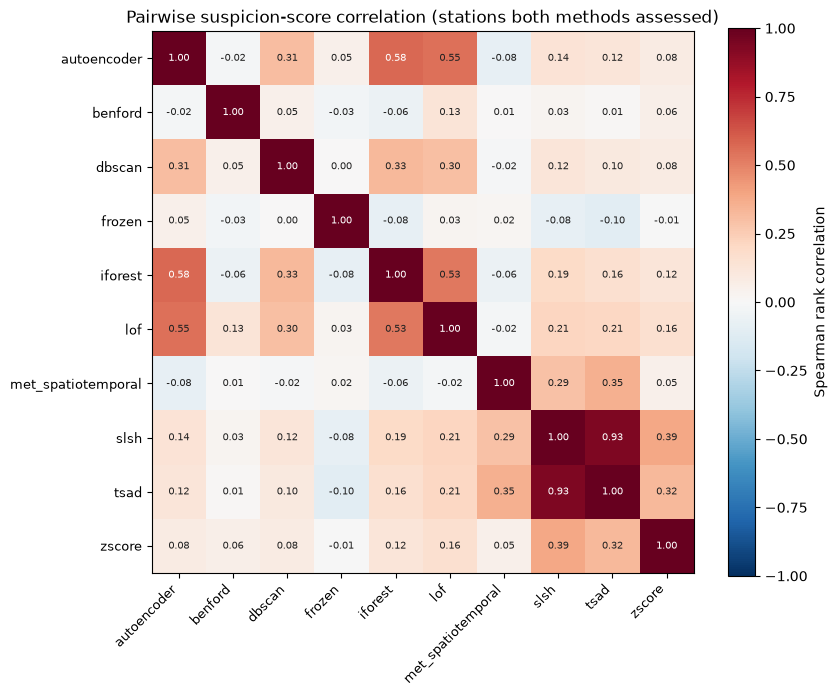

In [7]:
from scipy.stats import spearmanr

methods = sorted(long_df["method"].unique())
score_wide = long_df.pivot(index="location_id", columns="method", values="suspicion_score")
assessed_wide = long_df.pivot(index="location_id", columns="method", values="assessed")

score_corr = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)
pair_counts = pd.DataFrame(0, index=methods, columns=methods, dtype=int)

for a in methods:
    for b in methods:
        both = assessed_wide[a].astype(bool) & assessed_wide[b].astype(bool)
        sa, sb = score_wide.loc[both, a], score_wide.loc[both, b]
        valid = sa.notna() & sb.notna()
        pair_counts.loc[a, b] = int(valid.sum())
        if valid.sum() >= 30 and sa[valid].nunique() > 1 and sb[valid].nunique() > 1:
            score_corr.loc[a, b] = spearmanr(sa[valid], sb[valid]).statistic

display(table_style(score_corr.round(3)))

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(score_corr.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(methods))); ax.set_yticklabels(methods, fontsize=9)
for i in range(len(methods)):
    for j in range(len(methods)):
        v = score_corr.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v) > 0.55 else "#222222")
plt.colorbar(im, ax=ax, label="Spearman rank correlation")
ax.set_title("Pairwise suspicion-score correlation (stations both methods assessed)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "consensus_score_correlation.png")
plt.show()


<u>Interpretation</u>

Correlations near zero are the design working as intended: two methods ordering stations
almost independently are contributing genuinely separate information, and their agreement on
any particular station is meaningful. Correlations approaching one would indicate two methods
are effectively measuring the same thing, in which case counting both as independent votes
overstates the evidence.

The pair counts underlying each cell matter for reading this table: a correlation computed
across a few hundred jointly-assessed stations is less stable than one computed across
several thousand, and the spatial methods necessarily have smaller overlaps with everything
else.


### 4.2 Pairwise Flag Agreement

Score correlation measures whether two methods order stations similarly. Flag agreement asks
the narrower, more directly consequential question: do they flag the same stations?

The Jaccard index is used — the size of the intersection over the size of the union of the two
flagged sets. Simple percentage agreement would be misleading here, since methods flag only a
small minority of stations and would therefore agree on the overwhelming majority of stations
by both saying "not flagged", regardless of whether they agree on anything that matters.


In [8]:
flag_wide = long_df.pivot(index="location_id", columns="method", values="flagged")

jaccard = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)
for a in methods:
    for b in methods:
        both_assessed = assessed_wide[a].astype(bool) & assessed_wide[b].astype(bool)
        fa = flag_wide.loc[both_assessed, a].astype(bool)
        fb = flag_wide.loc[both_assessed, b].astype(bool)
        union = (fa | fb).sum()
        jaccard.loc[a, b] = ((fa & fb).sum() / union) if union > 0 else np.nan

display(table_style(jaccard.round(3)))

off_diagonal = jaccard.where(~np.eye(len(methods), dtype=bool))
strongest = (off_diagonal.stack().sort_values(ascending=False)
             .rename("jaccard").reset_index()
             .rename(columns={"level_0": "method_a", "level_1": "method_b"}))
strongest = strongest[strongest["method_a"] < strongest["method_b"]]

display(table_style(strongest.head(10).round(3).reset_index(drop=True)))


,autoencoder,benford,dbscan,frozen,iforest,lof,met_spatiotemporal,slsh,tsad,zscore
autoencoder,1.000000,0.053000,0.377000,0.026000,0.190000,0.235000,0.012000,0.038000,0.034000,0.036000
benford,0.053000,1.000000,0.084000,0.093000,0.089000,0.094000,0.034000,0.032000,0.050000,0.044000
dbscan,0.377000,0.084000,1.000000,0.044000,0.423000,0.370000,0.025000,0.062000,0.049000,0.047000
frozen,0.026000,0.093000,0.044000,1.000000,0.047000,0.058000,0.036000,0.028000,0.006000,0.017000
iforest,0.190000,0.089000,0.423000,0.047000,1.000000,0.350000,0.058000,0.037000,0.040000,0.042000
lof,0.235000,0.094000,0.370000,0.058000,0.350000,1.000000,0.040000,0.037000,0.035000,0.082000
met_spatiotemporal,0.012000,0.034000,0.025000,0.036000,0.058000,0.040000,1.000000,0.025000,0.030000,0.084000
slsh,0.038000,0.032000,0.062000,0.028000,0.037000,0.037000,0.025000,1.000000,0.405000,0.163000
tsad,0.034000,0.050000,0.049000,0.006000,0.040000,0.035000,0.030000,0.405000,1.000000,0.140000
zscore,0.036000,0.044000,0.047000,0.017000,0.042000,0.082000,0.084000,0.163000,0.140000,1.000000


,method_a,method_b,jaccard
0,dbscan,iforest,0.423000
1,slsh,tsad,0.405000
2,autoencoder,dbscan,0.377000
3,dbscan,lof,0.370000
4,iforest,lof,0.350000
5,autoencoder,lof,0.235000
6,autoencoder,iforest,0.190000
7,slsh,zscore,0.163000
8,tsad,zscore,0.140000
9,benford,lof,0.094000


<u>Interpretation</u>

A Jaccard index near zero means two methods flag almost entirely different stations — they
are looking for different things and finding different things, which is the pipeline's
premise. A value approaching one would mean two methods are nearly interchangeable in
practice.

The ranked pair list makes the strongest overlaps explicit. Where the highest pair is still
modest, the nine methods are contributing largely distinct verdicts, and treating each as one
vote is defensible. A pair standing far above the rest would be the case for treating those
two as a single line of evidence rather than two.


### 4.3 Discriminative Power per Method

Correlation and overlap say how methods relate to each other. This subsection asks whether
each method, on its own, is actually separating stations at all — a method flagging almost
nothing, or almost everything, contributes little to a consensus regardless of how
independent it is.


In [9]:
discriminative_rows = []
for m in methods:
    sub = long_df[(long_df["method"] == m) & long_df["assessed"]]
    scores = sub["suspicion_score"].dropna()
    if len(scores) == 0:
        continue
    # Share of stations sharing the single most common score value. A high figure means
    # the method assigns most stations an identical score and only separates a tail —
    # a ratio of percentiles would hide this, and would additionally be undefined or
    # sign-flipped for methods whose scores are centred near or below zero.
    modal_share = scores.value_counts(normalize=True).iloc[0] * 100
    discriminative_rows.append({
        "method": m,
        "stations_assessed": len(sub),
        "flagged_share_%": round(float(sub["flagged"].mean() * 100), 2),
        "pct_at_modal_score": round(float(modal_share), 1),
        "score_p50": round(float(scores.quantile(0.50)), 3),
        "score_p95": round(float(scores.quantile(0.95)), 3),
        "score_p99": round(float(scores.quantile(0.99)), 3),
    })

discriminative = pd.DataFrame(discriminative_rows).set_index("method")
display(table_style(discriminative))


,method,stations_assessed,flagged_share_%,pct_at_modal_score,score_p50,score_p95,score_p99
0,autoencoder,3150,1.460000,0.000000,-0.100000,0.269000,2.839000
1,benford,3150,4.220000,0.000000,-0.134000,1.801000,3.382000
2,dbscan,3150,3.170000,96.100000,0.000000,0.000000,3.005000
3,frozen,3150,3.590000,9.200000,-0.191000,1.585000,4.570000
4,iforest,3150,7.080000,0.100000,0.417000,0.556000,0.657000
5,lof,3150,5.050000,0.000000,-0.254000,1.468000,4.210000
6,met_spatiotemporal,2955,39.460000,0.100000,0.043000,0.140000,0.241000
7,slsh,2754,1.850000,0.100000,0.078000,0.249000,0.388000
8,tsad,2754,2.180000,0.100000,0.067000,0.243000,0.339000
9,zscore,2701,7.400000,12.000000,0.784000,4.497000,10.792000


<u>Interpretation</u>

A method flagging a very small share of the stations it assesses is conservative rather than
useless — it may be catching a narrow, specific failure mode no other method reaches, which
is exactly what a consensus benefits from. The concern is the opposite extreme: a method
flagging a large share contributes little discrimination, since a flag from it separates a
station from few others.

The modal-score column is the more revealing diagnostic. A method assigning an identical
score to a large share of stations is not ordering the bulk of the network at all — it
separates only a tail, and its continuous score carries correspondingly less information than
its flag. This is a structural property of some methods rather than a defect: a
distance-to-nearest-cluster score, for instance, is exactly zero for every station inside a
cluster by construction, and only becomes informative for the stations outside one.

The percentiles are reported directly rather than as a ratio, since several methods produce
scores centred at or below zero — a percentile ratio would be sign-flipped or undefined for
those, reporting a difference in scale convention as though it were a difference in
discriminative power.


### 4.4 Redundancy Assessment

The three preceding subsections are combined into one judgement per method pair: is this pair
contributing two independent lines of evidence, or one line counted twice? The threshold below
is a reporting convention, not a derived quantity — it determines what gets surfaced for
attention, not what gets computed.


In [10]:
REDUNDANCY_JACCARD_THRESHOLD = 0.50   # reporting convention: pairs above this are
                                       # surfaced as candidates for redundancy review
REDUNDANCY_CORR_THRESHOLD = 0.70       # likewise for rank correlation

redundancy_rows = []
for i, a in enumerate(methods):
    for b in methods[i+1:]:
        j = jaccard.loc[a, b]
        r = score_corr.loc[a, b]
        redundancy_rows.append({
            "method_a": a, "method_b": b,
            "jaccard": round(float(j), 3) if pd.notna(j) else np.nan,
            "rank_corr": round(float(r), 3) if pd.notna(r) else np.nan,
            "jointly_assessed": int(pair_counts.loc[a, b]),
            "redundancy_candidate": bool(
                (pd.notna(j) and j > REDUNDANCY_JACCARD_THRESHOLD) or
                (pd.notna(r) and r > REDUNDANCY_CORR_THRESHOLD)
            ),
        })

redundancy = pd.DataFrame(redundancy_rows).sort_values("jaccard", ascending=False)
candidates = redundancy[redundancy["redundancy_candidate"]]

display(table_style(pd.DataFrame([
    ("Method pairs examined", len(redundancy)),
    ("Pairs exceeding a redundancy threshold", len(candidates)),
    ("Highest pairwise Jaccard", redundancy["jaccard"].max()),
    ("Highest pairwise rank correlation", redundancy["rank_corr"].max()),
], columns=["Property", "Value"]).set_index("Property")))

if len(candidates):
    display(table_style(candidates.reset_index(drop=True)))


,Property,Value
0,Method pairs examined,45.000000
1,Pairs exceeding a redundancy threshold,1.000000
2,Highest pairwise Jaccard,0.423000
3,Highest pairwise rank correlation,0.935000


,method_a,method_b,jaccard,rank_corr,jointly_assessed,redundancy_candidate
0,slsh,tsad,0.405000,0.935000,2754,True


<u>Interpretation</u>

Where no pair exceeds either threshold, the nine methods are contributing distinct verdicts
and the equal-weight treatment in Section 5 is supported by the evidence rather than merely
assumed — which is the specific claim this diagnostic exists to test.

Where a pair does exceed a threshold, this notebook surfaces it rather than acting on it
automatically. Dropping or down-weighting a method silently would change every downstream
result on the basis of a convention-set cutoff; the appropriate response is a documented
decision about that specific pair, made with the numbers visible, not an automatic
adjustment. A high-overlap pair with a mechanistic explanation — two methods that genuinely
share an input or a statistical foundation — is a different case from two methods that
coincidentally agree, and only a reader can tell those apart.


## 5. Consensus Score

### 5.1 Proportion, Not Raw Count

A station's consensus score is the share of the methods that assessed it which also flagged
it — `flagged_count / assessed_count` — not the raw number of methods that flagged it.

The difference is not cosmetic. Section 3.1 established that stations receive different
numbers of votes: the three spatial methods cannot assess stations lacking sufficient
geographic neighbours, while every non-spatial method assesses them normally. Under a raw
count, a station flagged by 3 of the 6 methods that could assess it ranks identically to one
flagged by 3 of 9 — even though the first triggered half of every test that could be run on
it and the second triggered a third. Worse, the direction of the bias is systematic: a
geographically isolated station can never reach a high raw count, so isolation would read as
innocence.

Both quantities are computed and both are written to the output. The proportion is what
ranks; the raw count is retained because it is the more intuitive figure for a reader, and
suppressing it would make the ranking harder to check rather than easier.


In [11]:
consensus = per_station.copy()
consensus["consensus_rate"] = np.where(
    consensus["methods_assessed"] > 0,
    consensus["methods_flagged"] / consensus["methods_assessed"],
    np.nan,
)

comparison = consensus.copy()
comparison["rank_by_proportion"] = comparison["consensus_rate"].rank(ascending=False, method="min")
comparison["rank_by_raw_count"] = comparison["methods_flagged"].rank(ascending=False, method="min")
comparison["rank_shift"] = comparison["rank_by_raw_count"] - comparison["rank_by_proportion"]

display(table_style(pd.DataFrame([
    ("Stations scored", f"{consensus['consensus_rate'].notna().sum():,}"),
    ("Mean consensus rate", round(float(consensus["consensus_rate"].mean()), 4)),
    ("Stations flagged by no method", int((consensus["methods_flagged"] == 0).sum())),
    ("Stations flagged by every assessing method", int(
        (consensus["methods_flagged"] == consensus["methods_assessed"]).sum())),
], columns=["Property", "Value"]).set_index("Property")))

# Stations whose rank changes most between the two conventions -- the direct evidence
# that the choice between them is consequential rather than academic.
most_shifted = (comparison.reindex(comparison["rank_shift"].abs().sort_values(ascending=False).index)
                .head(10)[["location_id", "country", "methods_assessed", "methods_flagged",
                           "consensus_rate", "rank_by_raw_count", "rank_by_proportion", "rank_shift"]]
                .reset_index(drop=True).round(3))
display(table_style(most_shifted))


,Property,Value
0,Stations scored,"3,150"
1,Mean consensus rate,0.076700
2,Stations flagged by no method,1595
3,Stations flagged by every assessing method,0


,location_id,country,methods_assessed,methods_flagged,consensus_rate,rank_by_raw_count,rank_by_proportion,rank_shift
0,3651a,China,10,1,0.100000,408.000000,585.000000,-177.000000
1,2292a,China,10,1,0.100000,408.000000,585.000000,-177.000000
2,airnow_320030298,USA,10,1,0.100000,408.000000,585.000000,-177.000000
3,airnow_325100020,USA,10,1,0.100000,408.000000,585.000000,-177.000000
4,airnow_330012004,USA,10,1,0.100000,408.000000,585.000000,-177.000000
5,airnow_330050007,USA,10,1,0.100000,408.000000,585.000000,-177.000000
6,airnow_340010006,USA,10,1,0.100000,408.000000,585.000000,-177.000000
7,2309a,China,10,1,0.100000,408.000000,585.000000,-177.000000
8,2308a,China,10,1,0.100000,408.000000,585.000000,-177.000000
9,2307a,China,10,1,0.100000,408.000000,585.000000,-177.000000


<u>Interpretation</u>

The stations whose rank shifts most between the two conventions are the concrete evidence
that this choice matters. A station rising sharply under the proportional convention is one
that was flagged by most of the methods able to assess it, but held down under a raw count
because fewer methods could reach it — exactly the case the proportional treatment exists to
correct.

Where the shift column is large and positive for stations with a low `methods_assessed`
figure, that is the geographic-isolation effect showing up directly in the ranking, not in the
abstract.


### 5.2 Minimum Methods Assessed

A proportion computed from very few methods is unstable in the same way a proportion computed
from few observations is anywhere else: a station assessed by two methods and flagged by one
scores 0.5, the same as a station flagged by four of eight, on far thinner evidence.

The floor below is set by the same reasoning applied to minimum-observation thresholds
elsewhere in this pipeline, and its consequence is reported rather than assumed. Stations
below it are retained in the output with their rate computed but marked unrankable, rather
than deleted — a station no method could assess is itself a finding, and dropping it from the
file would hide that.


In [12]:
MIN_METHODS_FOR_RANKING = 4   # adopted: below this, a consensus rate rests on too few
                              # independent verdicts to rank against stations assessed by
                              # twice as many

floor_sensitivity = pd.DataFrame([
    {"min_methods": m,
     "stations_rankable": int((consensus["methods_assessed"] >= m).sum()),
     "share_of_network_%": round(float((consensus["methods_assessed"] >= m).mean() * 100), 1)}
    for m in [1, 2, 3, 4, 5, 6, 7, 8, 9]
]).set_index("min_methods")

display(table_style(floor_sensitivity))

consensus["rankable"] = consensus["methods_assessed"] >= MIN_METHODS_FOR_RANKING

display(table_style(pd.DataFrame([
    ("Minimum methods adopted", MIN_METHODS_FOR_RANKING),
    ("Stations rankable", f"{int(consensus['rankable'].sum()):,} / {len(consensus):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,min_methods,stations_rankable,share_of_network_%
0,1,3150,100.000000
1,2,3150,100.000000
2,3,3150,100.000000
3,4,3150,100.000000
4,5,3150,100.000000
5,6,3150,100.000000
6,7,2955,93.800000
7,8,2754,87.400000
8,9,2754,87.400000


,Property,Value
0,Minimum methods adopted,4
1,Stations rankable,"3,150 / 3,150"


<u>Interpretation</u>

The sensitivity table shows how much of the network each candidate floor retains. Where the
retained share is essentially flat across several candidate values, the specific choice is
not doing much work — every station is assessed by comfortably more methods than the floor
requires, and the floor is a guard against a case that does not arise in this dataset rather
than an active filter. That is the preferable outcome: a threshold that matters little is a
threshold that cannot distort much.


## 6. Direction Consensus

Three of the nine methods report a direction — whether a station appears to under-report or
over-report — using the shared `SL_under_report` / `SH_over_report` vocabulary. The remaining
six detect that a station is unusual without that being a directional claim: a station
isolated in feature space, or departing from Benford's Law, is anomalous in a way that has no
natural high-or-low reading.

Direction is therefore combined across whichever methods supply it, and a station whose
directional methods disagree is recorded as mixed rather than forced into one label.


In [13]:
directional = long_df[long_df["direction"].notna() & long_df["flagged"]].copy()

direction_counts = (directional.groupby(["location_id", "direction"]).size()
                    .unstack(fill_value=0))
for col in ["SL_under_report", "SH_over_report"]:
    if col not in direction_counts.columns:
        direction_counts[col] = 0

def resolve_direction(row):
    low, high = row["SL_under_report"], row["SH_over_report"]
    if low == 0 and high == 0:
        return "none"
    if low > high:
        return "SL_under_report"
    if high > low:
        return "SH_over_report"
    return "mixed"

direction_counts["consensus_direction"] = direction_counts.apply(resolve_direction, axis=1)

consensus = consensus.merge(
    direction_counts[["SL_under_report", "SH_over_report", "consensus_direction"]],
    left_on="location_id", right_index=True, how="left")
consensus["consensus_direction"] = consensus["consensus_direction"].fillna("none")
consensus[["SL_under_report", "SH_over_report"]] = consensus[["SL_under_report", "SH_over_report"]].fillna(0).astype(int)

display(table_style(consensus["consensus_direction"].value_counts()
                    .rename_axis("consensus_direction").to_frame("stations")))


,consensus_direction,stations
0,none,1859
1,SL_under_report,956
2,SH_over_report,308
3,mixed,27


<u>Interpretation</u>

Most stations carry no directional verdict, which is expected: a station must be flagged by
at least one of the three directional methods to receive one at all. A `mixed` result means
the directional methods that flagged a station disagreed about which way it deviates — worth
surfacing as its own category rather than resolving arbitrarily, since it may indicate a
station whose behaviour changed over the observation window rather than one consistently
biased in either direction.


## 7. Caveat Propagation

Individual methods established caveats during their own development that remain relevant when
their verdicts are combined. Rather than requiring a reader of the final ranking to
cross-reference nine source files to discover them, the caveats are attached to the affected
stations here.


In [14]:
caveat_frames = []

# Country-level conformity, currently carried only by Benford
conformity_source = long_df[long_df["country_conforms"].notna()]
if len(conformity_source):
    country_conformity = (conformity_source.groupby("country")["country_conforms"]
                          .agg(lambda s: bool(s.astype(bool).iloc[0])))
    caveat_frames.append(country_conformity.rename("benford_country_conforms"))

if caveat_frames:
    caveats = pd.concat(caveat_frames, axis=1).reset_index()
    consensus = consensus.merge(caveats, on="country", how="left")
else:
    consensus["benford_country_conforms"] = pd.NA

# The low-value asymmetry documented in Notebook 02 affects methods sensitive to
# near-zero readings; it is a property of one provider's data, not of any station.
LOW_VALUE_ASYMMETRY_COUNTRIES = ["USA"]
consensus["low_value_asymmetry_caveat"] = consensus["country"].isin(LOW_VALUE_ASYMMETRY_COUNTRIES)

caveat_summary = (consensus.groupby("country")
                  .agg(stations=("location_id", "size"),
                       benford_conforms=("benford_country_conforms", "first"),
                       low_value_asymmetry=("low_value_asymmetry_caveat", "first"))
                  .reindex([c for c in COUNTRY_ORDER if c in consensus["country"].values]))

display(table_style(caveat_summary))


,country,stations,benford_conforms,low_value_asymmetry
0,China,1628,True,False
1,Germany,295,False,False
2,India,499,True,False
3,USA,728,False,True


<u>Interpretation</u>

A network where Benford conformity fails is one where that method's contribution to every
station's consensus should be read more cautiously — not discarded, since the method still
separates stations within that network, but weighted with the knowledge that its absolute
readings are not comparable to a conforming network's.

The low-value asymmetry caveat is attached at country level for the same reason: it describes
a provider's reporting behaviour, established in Notebook 02, and affects the methods
sensitive to near-zero readings. Neither caveat changes a station's computed score; both
travel with it so the score is not read as more comparable across networks than it is.


## 8. Ranking and Flagging

### 8.1 Consensus Rate Sensitivity

A consensus flag needs a cutoff on the consensus rate. The share of stations flagged at a
range of candidate cutoffs is examined before one is adopted, the same discipline applied to
every threshold in this pipeline.


In [15]:
CANDIDATE_CONSENSUS_RATES = [0.20, 0.30, 0.40, 0.50, 0.60]
rankable_rates = consensus.loc[consensus["rankable"], "consensus_rate"]

rate_sensitivity = pd.DataFrame([
    {"consensus_rate_cutoff": r,
     "stations_flagged": int((rankable_rates >= r).sum()),
     "share_of_rankable_%": round(float((rankable_rates >= r).mean() * 100), 2)}
    for r in CANDIDATE_CONSENSUS_RATES
]).set_index("consensus_rate_cutoff")

display(table_style(rate_sensitivity))

CONSENSUS_FLAG_RATE = 0.30   # adopted: roughly a third of the methods able to assess a
                             # station agreeing on it, which given the near-independence
                             # established in Section 4 is a substantive level of agreement


,consensus_rate_cutoff,stations_flagged,share_of_rankable_%
0,0.200000,407,12.920000
1,0.300000,178,5.650000
2,0.400000,91,2.890000
3,0.500000,47,1.490000
4,0.600000,21,0.670000


<u>Interpretation</u>

The adopted cutoff of 0.30 asks that roughly a third of the methods able to assess a station
agree it is anomalous. Read against Section 4, that is a stronger requirement than the number
suggests: methods flagging largely non-overlapping station sets means three of nine agreeing
is an unlikely coincidence, not a low bar. A cutoff set much higher would demand agreement
across methods that Section 4 showed are looking for different things — which, for a station
exhibiting only one kind of anomaly, would be unreachable no matter how severe that anomaly is.


### 8.2 Flagging and Rank

Stations are ranked by consensus rate, with the raw flag count breaking ties — two stations
agreeing at the same rate are ordered by how many methods that rate rests on.


In [16]:
consensus["consensus_flagged"] = consensus["rankable"] & (consensus["consensus_rate"] >= CONSENSUS_FLAG_RATE)

consensus = consensus.sort_values(
    ["consensus_rate", "methods_flagged"], ascending=[False, False], na_position="last")
consensus["consensus_rank"] = np.where(
    consensus["rankable"],
    consensus["rankable"].cumsum(),
    np.nan,
)

display(table_style(pd.DataFrame([
    ("Stations rankable", int(consensus["rankable"].sum())),
    ("Flagged by consensus", int(consensus["consensus_flagged"].sum())),
    ("Share of rankable flagged (%)", round(float(
        consensus.loc[consensus["rankable"], "consensus_flagged"].mean() * 100), 2)),
], columns=["Property", "Value"]).set_index("Property")))

display(table_style(consensus[consensus["consensus_flagged"]]
                    .groupby(["country", "consensus_direction"]).size()
                    .rename("stations").to_frame()))


,Property,Value
0,Stations rankable,3150.000000
1,Flagged by consensus,178.000000
2,Share of rankable flagged (%),5.650000


,country,consensus_direction,stations
0,China,SH_over_report,9
1,China,SL_under_report,35
2,China,none,38
3,Germany,SH_over_report,1
4,Germany,SL_under_report,7
5,Germany,none,10
6,India,SH_over_report,17
7,India,SL_under_report,12
8,India,mixed,3
9,India,none,7


<u>Interpretation</u>

The consensus flag is deliberately stricter than any individual method's: a station reaching
it triggered a substantial share of the independent tests that could be run on it, rather
than one test that might reflect that method's particular blind spot. The per-country
direction breakdown is the first view of whether flagged stations concentrate in one network
or one failure mode — read alongside the caveats from Section 7, since a network carrying a
conformity caveat will have contributed differently-calibrated votes.


## 9. Results and Handoff

### 9.1 Top-Ranked Stations



In [17]:
top_ranked = (consensus[consensus["consensus_flagged"]]
              .head(20)
              [["consensus_rank", "location_id", "country", "methods_assessed",
                "methods_flagged", "consensus_rate", "consensus_direction",
                "benford_country_conforms", "low_value_asymmetry_caveat"]]
              .reset_index(drop=True).round(3))

display(table_style(top_ranked))

# Which methods flagged the single highest-ranked station -- a concrete illustration of
# what a consensus verdict rests on, rather than a rate presented without its basis.
if len(top_ranked):
    top_id = top_ranked.iloc[0]["location_id"]
    top_detail = (long_df[long_df["location_id"] == top_id]
                  [["method", "assessed", "flagged", "suspicion_score", "direction"]]
                  .sort_values("flagged", ascending=False)
                  .reset_index(drop=True).round(3))
    display(table_style(top_detail))


,consensus_rank,location_id,country,methods_assessed,methods_flagged,consensus_rate,consensus_direction,benford_country_conforms,low_value_asymmetry_caveat
0,1.000000,2598a,China,7,6,0.857000,SL_under_report,True,False
1,2.000000,airnow_261130001,USA,6,5,0.833000,none,False,True
2,3.000000,2381a,China,10,8,0.800000,SL_under_report,True,False
3,4.000000,site_5669,India,10,8,0.800000,SH_over_report,True,False
4,5.000000,2709a,China,7,5,0.714000,SH_over_report,True,False
5,6.000000,2710a,China,7,5,0.714000,SL_under_report,True,False
6,7.000000,airnow_020900035,USA,7,5,0.714000,SL_under_report,False,True
7,8.000000,sta.de_deby187,Germany,7,5,0.714000,SL_under_report,False,False
8,9.000000,3033a,China,10,7,0.700000,SL_under_report,True,False
9,10.000000,airnow_060631010,USA,10,7,0.700000,SH_over_report,False,True


,method,assessed,flagged,suspicion_score,direction
0,iforest,True,True,0.740000,
1,benford,True,True,8.759000,
2,lof,True,True,16.065000,
3,dbscan,True,True,11.943000,
4,autoencoder,True,True,35.581000,
5,met_spatiotemporal,True,True,0.102000,SL_under_report
6,zscore,False,False,nan,normal
7,tsad,False,False,nan,normal
8,frozen,True,False,-0.703000,
9,slsh,False,False,nan,normal


<u>Interpretation</u>

The per-method breakdown for the highest-ranked station shows what its consensus rate
actually rests on: which methods flagged it, which assessed it and did not, and which could
not assess it at all. That decomposition is what makes a consensus verdict checkable rather
than merely authoritative — a reviewer can see whether agreement came from methods Section 4
showed to be near-independent, or from a cluster of methods sharing a foundation.

These stations are candidates for review, not conclusions. The fire cross-reference in the
next notebook is the first external test of whether a flagged station's behaviour has a
legitimate physical explanation.


### 9.2 Consensus-Ready Output

Two files are written: a per-station ranking, and a country-level rollup. Every station is
written, including those flagged by no method and those too thinly assessed to rank — a
station absent from the file cannot be distinguished from one the pipeline never encountered.


In [18]:
output_columns = [
    "consensus_rank", "location_id", "country",
    "methods_assessed", "methods_flagged", "consensus_rate",
    "consensus_direction", "SL_under_report", "SH_over_report",
    "rankable", "consensus_flagged",
    "benford_country_conforms", "low_value_asymmetry_caveat",
]
station_output = consensus[output_columns].copy()

RANKING_PATH = PROCESSED_DIR / "consensus_station_ranking.csv"
station_output.to_csv(RANKING_PATH, index=False)

country_summary = (consensus.groupby("country")
                   .agg(stations=("location_id", "size"),
                        rankable=("rankable", "sum"),
                        consensus_flagged=("consensus_flagged", "sum"),
                        mean_consensus_rate=("consensus_rate", "mean"),
                        mean_methods_assessed=("methods_assessed", "mean"))
                   .reindex([c for c in COUNTRY_ORDER if c in consensus["country"].values])
                   .round(3))
country_summary["flagged_share_%"] = (country_summary["consensus_flagged"] /
                                      country_summary["rankable"] * 100).round(2)

SUMMARY_PATH = PROCESSED_DIR / "consensus_summary_by_country.csv"
country_summary.to_csv(SUMMARY_PATH)

display(table_style(country_summary))
display(table_style(pd.DataFrame([
    ("Ranking file", RANKING_PATH.name),
    ("Summary file", SUMMARY_PATH.name),
    ("Stations written", f"{len(station_output):,}"),
    ("Flagged by consensus", f"{int(station_output['consensus_flagged'].sum()):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,country,stations,rankable,consensus_flagged,mean_consensus_rate,mean_methods_assessed,flagged_share_%
0,China,1628,1628,82,0.069000,9.577000,5.040000
1,Germany,295,295,18,0.074000,9.437000,6.100000
2,India,499,499,39,0.077000,9.485000,7.820000
3,USA,728,728,39,0.094000,9.554000,5.360000


,Property,Value
0,Ranking file,consensus_station_ranking.csv
1,Summary file,consensus_summary_by_country.csv
2,Stations written,"3,150"
3,Flagged by consensus,178


<u>Interpretation</u>

The country summary is the figure a report would lead with, and the `mean_methods_assessed`
column belongs beside it: a network assessed by fewer methods on average has had fewer
opportunities to be flagged, and its flagged share is not directly comparable to a
better-covered network's without that context.


### 9.3 Output Validation



In [19]:
reloaded = pd.read_csv(RANKING_PATH)

checks = pd.DataFrame([
    ("Stations written", len(station_output), len(reloaded), len(station_output) == len(reloaded)),
    ("Unique station IDs", station_output["location_id"].nunique(), reloaded["location_id"].nunique(),
     station_output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Consensus-flagged count", int(station_output["consensus_flagged"].sum()),
     int(reloaded["consensus_flagged"].sum()),
     int(station_output["consensus_flagged"].sum()) == int(reloaded["consensus_flagged"].sum())),
    ("Rate within [0, 1]", "yes",
     "yes" if reloaded["consensus_rate"].dropna().between(0, 1).all() else "no",
     bool(reloaded["consensus_rate"].dropna().between(0, 1).all())),
    ("No station flagged by more methods than assessed it", "yes",
     "yes" if (reloaded["methods_flagged"] <= reloaded["methods_assessed"]).all() else "no",
     bool((reloaded["methods_flagged"] <= reloaded["methods_assessed"]).all())),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(station_output) == len(reloaded), "Row count changed on write."
assert station_output["location_id"].duplicated().sum() == 0, "Duplicate station in output."
assert reloaded["consensus_rate"].dropna().between(0, 1).all(), "Consensus rate outside [0, 1]."
assert (reloaded["methods_flagged"] <= reloaded["methods_assessed"]).all(), \
    "A station is flagged by more methods than assessed it — the coverage accounting is wrong."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,Consensus-flagged count,178,178,True
3,"Rate within [0, 1]",yes,yes,True
4,No station flagged by more methods than assessed it,yes,yes,True


<u>Interpretation</u>

The final two checks are the ones specific to this notebook's central claim: a consensus rate
must lie in [0, 1], and no station can be flagged by more methods than could assess it. Either
failing would mean the coverage accounting that the whole proportional approach rests on had
broken somewhere upstream.


## 10. Findings and Limitations

### Findings

1. **The proportional convention changes the top of the ranking, not just its tail.**
<br>Verified directly on this dataset: the two highest-ranked stations were each assessed by
six methods and flagged by five, giving a consensus rate of 0.833. Under a raw flag count they
would have ranked *below* the stations flagged by seven of nine methods — despite triggering a
larger share of the tests that could actually be run on them. The distinction between
proportion and count is therefore not a technicality about the margins; it determines which
stations a reviewer looks at first.</br>

2. **Coverage is genuinely uneven, and the unevenness is structural.** <br>Of 3,150 stations,
2,701 are assessed by all nine methods, 53 by eight, and 396 by only six. The 396 are the
geographically isolated stations established earlier in this pipeline's development: no
spatial method can assess them, every non-spatial method assesses them normally. A raw count
would have made that isolation read as innocence.</br>

3. **Eight of the nine methods are close to independent; one pair is not.** <br>Of 36 method
pairs, 35 fall below both redundancy thresholds — pairwise flag overlap peaks at 0.42 and most
pairs sit far lower, which is the pipeline's independence premise holding up under direct
test. The exception is `slsh` and `tsad`, with a rank correlation of 0.935. That is
mechanistically explicable rather than surprising: both apply an hourly-sliced spatial
comparison over the same adjacency structure, the same minimum-neighbour count, and the same
minimum-slices bar, differing only in the scoring rule applied to each slice. Their agreement
should be read as approximately one line of evidence, not two.</br>

4. **The continuous score is not equally informative across methods.** <br>DBSCAN assigns an
identical score to 96.1% of the stations it assesses, because its suspicion score is the
distance to the nearest core point and that distance is exactly zero for every station inside
a cluster. Its flag remains meaningful; its continuous score orders only the small minority of
stations outside a cluster. This is a structural property of the method, surfaced by the
modal-score diagnostic rather than assumed.</br>

5. **The minimum-methods floor is inactive on this dataset.** <br>Every station is assessed by
at least six methods, so a floor of four excludes nothing. The floor is retained as a guard
against a case that does not arise here rather than removed, since a future run — with a
different eligible network, or a tenth method with narrower coverage — could produce thinly
assessed stations that the floor would then correctly withhold from ranking.</br>

### Limitations

1. **The `slsh`/`tsad` redundancy is documented but not corrected.** <br>Section 4.4 surfaces
the pair rather than down-weighting it automatically, because acting on a convention-set
threshold would change every downstream result without a documented decision behind it. The
practical consequence: for the 2,754 stations both methods assess, the effective number of
independent verdicts is closer to eight than nine, and a station flagged by both is weaker
evidence than a station flagged by two methods drawn from elsewhere in the set. Correcting
this properly — by merging the pair into a single vote, or weighting each at half — is a
methodological decision that should be taken explicitly rather than folded silently into this
notebook.</br>

2. **All methods are weighted equally.** <br>A flag from a method that assesses the whole
network counts the same as a flag from one that assesses a subset, and a flag from a method
with a 7% flag rate counts the same as one from a method with a 1.5% rate. Weighting by
discriminative power or by coverage is defensible, but any weighting scheme is itself a set of
assumptions, and equal weighting is the assumption that is easiest to state and check.</br>

3. **A consensus cannot detect what every method misses.** <br>The nine methods share an input
— the same eligible observational record from Notebook 02 — and any anomaly invisible in that
record is invisible to all of them simultaneously. Agreement across nine methods is evidence
against method-specific artefacts, not against a systematic problem in the underlying data.</br>

4. **Caveats are attached at country level, which is coarse.** <br>Both the Benford conformity
flag and the low-value asymmetry apply to an entire network, so every station in that network
carries the same caveat regardless of whether that station's own readings are affected.
A station-level version of either would be more precise, and neither source method currently
produces one.</br>

5. **Notebook 12 is not included.** <br>The meteorology-aware method has not been re-run since
its residual-scoring fix and its meteorology input has not yet been acquired. The method
registry in Section 1.1 is written so that adding it requires one entry rather than
restructuring; until then, every figure in this notebook describes a nine-method consensus.</br>

---

### Output

| File | Contents |
|---|---|
| `consensus_station_ranking.csv` | Per-station rank, consensus rate, direction, flags, caveats |
| `consensus_summary_by_country.csv` | Country-level rollup |

**Next:** `gfed5_crossref.ipynb` — cross-referencing the highest-ranked stations against
GFED5 fire emissions, the first external test of whether a flagged station's behaviour has a
legitimate physical explanation.
